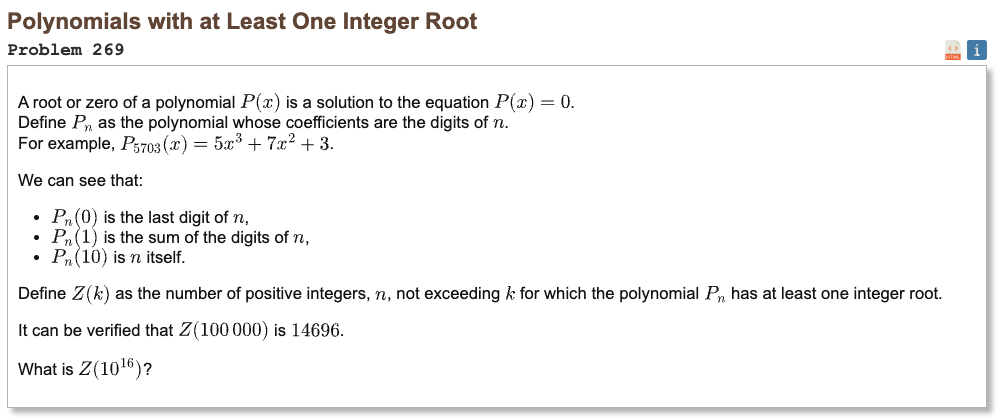

## Initial approach

* only 0 or negative numbers can be integer roots here, because all digits are nonnegative
* if a negative root exists, its size must fit into the last digit, so only a very small set of roots can ever matter
* root 0 is easy, it just means the number ends in 0
* for the other roots, build the factor and count only digit strings of one fixed length that are divisible by that factor
* work from the low digits upward and keep a small state that represents the quotient coefficients still needed to make every digit stay between 0 and 9
* use inclusion exclusion on the possible root sets, but skip almost all subsets because their required product is already too large for a decimal last digit
* for a limit like 10^16, the root 0 part separates cleanly, so you only need the exact 16 digit counts for the nonzero root sets
* use itertools to generate the valid root subsets easily

In [1]:
from itertools import combinations

def poly_mul(a, b):
    c = [0] * (len(a) + len(b) - 1)
    for i, x in enumerate(a):
        for j, y in enumerate(b):
            c[i + j] += x * y
    return tuple(c)

def count_exact_length_nonzero(F, length):
    m = len(F) - 1
    d = length - 1
    if d < m:
        return 0

    steps = d - m
    c0 = F[0]
    states = {(): 1}

    for n in range(m):
        new_states = {}
        for prefix, cnt in states.items():
            const = 0
            for j in range(1, n + 1):
                const += F[j] * prefix[n - j]
            for digit in range(10):
                diff = digit - const
                if diff % c0 == 0:
                    key = prefix + (diff // c0,)
                    new_states[key] = new_states.get(key, 0) + cnt
        states = new_states

    for _ in range(steps):
        new_states = {}
        for state, cnt in states.items():
            const = state[0]
            for r in range(1, m):
                const += F[m - r] * state[r]
            suffix = state[1:]
            for digit in range(10):
                diff = digit - const
                if diff % c0 == 0:
                    key = suffix + (diff // c0,)
                    new_states[key] = new_states.get(key, 0) + cnt
        states = new_states

    total = 0
    for state, cnt in states.items():
        if 1 <= state[0] <= 9 and all(x == 0 for x in state[1:]):
            total += cnt
    return total

def valid_root_sets():
    roots = []
    for r in range(1, 10):
        for comb in combinations(range(1, 10), r):
            p = 1
            for x in comb:
                p *= x
            if p <= 9:
                roots.append(comb)
    return roots

def z_power_of_10(power):
    total = 10 ** (power - 1)

    for comb in valid_root_sets():
        F = (1,)
        for k in comb:
            F = poly_mul(F, (k, 1))

        ways = count_exact_length_nonzero(F, power)
        if len(comb) % 2 == 1:
            total += ways
        else:
            total -= ways

    return total

In [2]:
%%time
sample = z_power_of_10(5)
result = z_power_of_10(16)
print("Result:", result)

Result: 1311109198529286
CPU times: user 14.2 ms, sys: 1.27 ms, total: 15.5 ms
Wall time: 15.2 ms
